# Experiment 3 — QELM and QRC on Real Data

This notebook evaluates the ORS gap and $R_{\rm eff}$ expressivity diagnostics on two real-world quantum machine learning benchmarks.
The central question: do circuits with higher ORS gap and larger $R_{\rm eff}$ achieve lower prediction error on practical tasks?

| # | Task | Model | Qubits | Performance |
|---|------|-------|--------|-------------|
| 1 | LiH excited-state energy prediction | QELM | 8 | MSE ↓ |
| 2 | EMSIG electricity demand forecasting | QRC  | 3 | R² ↑  |

## Diagnostics

The **ORS gap** $\Lambda - \Lambda_{\rm Haar}$ quantifies how much more expressive a circuit is than a Haar-random one: positive values mean the circuit's output distribution over Haar-random inputs concentrates its probability mass more strongly in the top-$K$ outcomes, indicating richer expressivity. It is estimated from $B=5$ random Pauli measurement bases and averaged over 100 random circuit instances.

The **effective rank** $R_{\rm eff} = (\sum_i \sigma_i)^2 / \sum_i \sigma_i^2$ (from the SVD of the centred feature matrix) measures how many independent dimensions the reservoir actually uses: a higher $R_{\rm eff}$ indicates a more diverse, less redundant feature set.

See **Exp1** and **Exp2** for derivations and synthetic-task validation.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from metrics import lambda_haar_largeD
from QELM import QuantumCircQiskit

FAMILY_COLORS = {
    'Haar': '#000000', 'G1': 'royalblue', 'G2': 'mediumseagreen', 'G3': 'crimson',
    'D2_random': '#9467bd', 'D2_random_XZ': '#e377c2', 'D2_random_XZY': 'tab:orange',
}
FAMILY_MARKERS = {
    'Haar': 'o', 'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}
G_FAMILIES  = ['G1', 'G2', 'G3']
D2_FAMILIES = ['D2_random', 'D2_random_XZ', 'D2_random_XZY']

NOISY_BASIS_DIR = os.path.join('results', 'ors', 'noisy_basis')
B     = 5    # number of Pauli bases for ORS mean / std  ← change here
K     = 4    # ORS top-K
F_ORS = 1.0  # measurement fidelity

os.makedirs('figures', exist_ok=True)

In [11]:
def effective_rank(F, eps=1e-12):
    """Participation ratio of singular values: sum(sv)^2 / sum(sv^2)."""
    F = F - F.mean(axis=0, keepdims=True)
    try:
        sv = np.linalg.svd(F, compute_uv=False)
    except np.linalg.LinAlgError:
        from scipy.linalg import svd as sp_svd
        sv = sp_svd(F, compute_uv=False, lapack_driver='gesvd')
    sv = sv[sv > eps]
    if len(sv) == 0:
        return 0.0
    return float(sv.sum()**2 / (sv**2).sum())


def load_ors_mb(fam, val, kind, n, f=F_ORS, K=K):
    """Load ORS gap (mean, std) from noisy_basis file; first B bases.

    Returns (nan, nan) if file or key is missing.
    kind='ng'  → G-family,  filename suffix _ng{val}
    kind='deg' → D2-family, filename suffix _deg{val}_L1
    """
    ftag   = f'{f:.2f}'.replace('.', 'p')
    suffix = f'_ng{val}' if kind == 'ng' else f'_deg{val}_L1'
    path   = os.path.join(NOISY_BASIS_DIR,
                          f'{fam}{suffix}_100runs_seed1234_basis4321_noise_multibasis.npz')
    if not os.path.exists(path):
        print('Path does not exist: ', path)
        return np.nan, np.nan
    d   = np.load(path)
    key = f'gap_n{n}_K{K}_f{ftag}'
    if key not in d.files:
        print('key does not exist: ', key)
        return np.nan, np.nan
    gap = d[key][:B]
    return float(gap.mean()), float(gap.std()/B)


def plot_diagnostics(g_results, d_results, haar_ref,
                     metric_label='MSE', log_metric=True, save_path=None):
    """3×2 diagnostic figure.

    Rows: ORS gap / R_eff / performance.  Cols: G-families / D2-families.

    g_results, d_results : {family: {x_val: {ors_m, ors_s, reff_m, reff_s, metric_m, metric_s}}}
    haar_ref             : {ors: 0.0, reff: scalar|None, metric: scalar|None}
    """
    fig, axes = plt.subplots(3, 2, figsize=(13, 10))

    col_specs = [
        (0, g_results,  G_FAMILIES,  'Number of gates', 'G-families'),
        (1, d_results,  D2_FAMILIES, 'Degree',          'D2-families'),
    ]
    row_keys   = ['ors',   'reff',          'metric']
    row_labels = [r'$\Lambda - \Lambda_{\rm Haar}$',
                  r'$R_{\rm eff}$',
                  metric_label]

    for col, results, fams, xlabel, title in col_specs:
        for row, rkey in enumerate(row_keys):
            ax = axes[row, col]

            for fam in fams:
                if fam not in results or not results[fam]:
                    continue
                xs   = sorted(results[fam])
                ys_m = np.array([results[fam][x][f'{rkey}_m'] for x in xs])
                ys_s = np.array([results[fam][x][f'{rkey}_s'] for x in xs])
                valid = np.isfinite(ys_m)
                if not valid.any():
                    continue
                xv = np.array(xs)[valid]
                ax.plot(xv, ys_m[valid],
                        color=FAMILY_COLORS[fam], marker=FAMILY_MARKERS[fam],
                        lw=2, ms=6, label=fam)
                ax.fill_between(xv,
                                (ys_m - ys_s)[valid], (ys_m + ys_s)[valid],
                                color=FAMILY_COLORS[fam], alpha=0.18)

            href = haar_ref.get(rkey)
            if href is not None:
                ax.axhline(href, color='k', ls='--', lw=1.2, alpha=0.55, label='Haar')
            elif rkey == 'ors':
                ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.55, label='Haar')

            ax.set_xscale('log')
            ax.set_xlabel(xlabel, fontsize=14)
            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=14)
            if row == 0:
                ax.set_title(title, fontsize=14)
            if row == 2 and log_metric:
                ax.set_yscale('log')
            ax.grid(True, which='both', alpha=0.3)

    seen = {}
    for ax in axes[0]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            seen.setdefault(l, h)
    for h, l in zip(*ax.get_legend_handles_labels()):
        seen.setdefault(l, h)
    fig.legend(seen.values(), seen.keys(), loc='upper center',
               bbox_to_anchor=(0.5, -0.01), ncol=len(seen), fontsize=13, frameon=False)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

## Part 1: QELM on LiH Excited-State Energy Prediction

**Dataset.** We use 300 geometries of the lithium hydride (LiH) molecule, sampled by varying the bond length from 0.5 Å to 4.0 Å. At each geometry we have the full ground-state wavefunction $|\psi_0\rangle \in \mathbb{C}^{256}$ (8 qubits) obtained from an exact diagonalisation, and the four lowest energy eigenvalues.

**Task.** Given $|\psi_0\rangle$, predict the first two excitation energies $E_1 - E_0$ and $E_2 - E_0$ (Hartree).

**Protocol (QELM).** The ground state is amplitude-encoded into an 8-qubit register via Ry rotations ($\theta_i = 2\arcsin(a_i)$). A fixed, random quantum circuit (the *reservoir*) then entangles the qubits. The expectation values of $k$-local Pauli observables form the feature vector, which is passed to a Ridge regression readout. The circuit is never trained; only the linear readout is fitted.

**Sweep.** We vary the circuit family and its complexity parameter (gate depth for G-families, expected graph degree for D2-families), running 100 independent random reservoir instances per configuration.

Bond lengths: 0.50 – 3.49 Å  (300 geometries, 8 qubits)


QELM features: 100%|██████████| 300/300 [01:00<00:00,  4.99it/s]


Haar QELM  MSE = 1.1210e-07


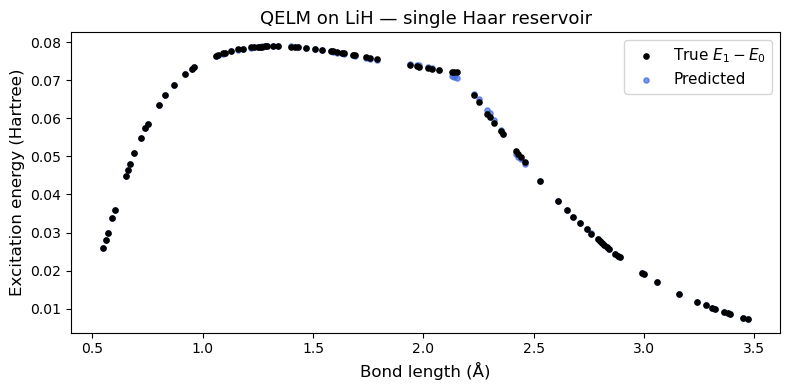

In [3]:
# ── Load LiH dataset ──────────────────────────────────────────────────────────
spectra       = np.load(os.path.join('data', 'LiH', 'spectrums_LiH.npy'))       # (300, 4)
bond_lengths  = np.load(os.path.join('data', 'LiH', 'bond_lengths_LiH.npy'))    # (300,)
ground_states = np.load(os.path.join('data', 'LiH', 'ground_states_LiH.npy'))   # (300, 256)
nqbits = int(np.log2(ground_states.shape[1]))  # 8

# Excitation energies as regression targets
y = np.stack([spectra[:, 1] - spectra[:, 0],
              spectra[:, 2] - spectra[:, 0]], axis=1)   # (300, 2)

print(f'Bond lengths: {bond_lengths.min():.2f} – {bond_lengths.max():.2f} Å  '
      f'({len(bond_lengths)} geometries, {nqbits} qubits)')

# ── Single Haar reservoir example ─────────────────────────────────────────────
np.random.seed(0)
qrc = QuantumCircQiskit('Haar', nqbits=nqbits, statevector=True)
X   = np.array([qrc.run_circuit(gs) for gs in tqdm(ground_states, desc='QELM features')])

X_tr, X_te, y_tr, y_te, bl_tr, bl_te = train_test_split(
    X, y, bond_lengths, test_size=0.33, random_state=42)

scaler = MinMaxScaler()
y_hat  = scaler.inverse_transform(
    Ridge(alpha=1e-12).fit(X_tr, scaler.fit_transform(y_tr)).predict(X_te))

mse = np.mean((y_hat - y_te) ** 2)
print(f'Haar QELM  MSE = {mse:.4e}')

# ── Plot predicted vs true first excitation energy ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(bl_te, y_te[:, 0],  s=14, c='k',         label=r'True $E_1 - E_0$',     zorder=3)
ax.scatter(bl_te, y_hat[:, 0], s=14, c='royalblue',  alpha=0.7, label='Predicted',  zorder=2)
ax.set_xlabel('Bond length (Å)', fontsize=12)
ax.set_ylabel('Excitation energy (Hartree)', fontsize=12)
ax.set_title('QELM on LiH — single Haar reservoir', fontsize=13)
ax.legend(fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join('figures', 'lih_example.png'), dpi=150)
plt.show()

In [7]:
QRC_DIR_LIH   = os.path.join('results', 'qelm', 'chemistry', 'LiH')
N_LIH, NS_LIH = 8, 100
G_DEPTHS_LIH   = [10, 20, 50, 100, 200, 1000]
D2_DEGREES_LIH = [1, 2, 4, 6, 8, 10]


def _lih_path(fam, val, kind):
    if fam == 'Haar':
        return os.path.join(QRC_DIR_LIH, f'Haar_{N_LIH}q_{NS_LIH}runs.npz')
    tag = f'depth{val}' if kind == 'ng' else f'deg{val}'
    return os.path.join(QRC_DIR_LIH, f'{fam}_{tag}_{N_LIH}q_{NS_LIH}runs.npz')


def _load_lih(fam, val, kind):
    path = _lih_path(fam, val, kind)
    if not os.path.exists(path):
        return None
    d = np.load(path)
    # Compute R_eff from obs_res_all if not yet stored, then save back
    if 'reff' not in d.files:
        obs  = d['obs_res_all']   # (ns, T, n_obs)
        reff = np.array([effective_rank(obs[i]) for i in range(obs.shape[0])])
        payload = {k: d[k] for k in d.files}
        payload['reff'] = reff
        np.savez_compressed(path, **payload)
        d = np.load(path)
    # ORS gap from noisy_basis (returns nan, nan when file is missing)
    ors_m, ors_s = load_ors_mb(fam, val, kind, N_LIH)
    reff = d['reff']
    mse  = d['mse_all']
    return dict(
        ors_m=ors_m,    ors_s=ors_s,
        reff_m=float(reff.mean()), reff_s=float(reff.std() / np.sqrt(len(reff))),
        metric_m=float(mse.mean()), metric_s=float(mse.std() / np.sqrt(len(mse))),
    )


# ── Build result dicts ─────────────────────────────────────────────────────────
lih_g_results = {fam: {} for fam in G_FAMILIES}
for fam in G_FAMILIES:
    for depth in tqdm(G_DEPTHS_LIH, desc=fam, leave=False):
        r = _load_lih(fam, depth, 'ng')
        if r:
            lih_g_results[fam][depth] = r

lih_d_results = {fam: {} for fam in D2_FAMILIES}
for fam in D2_FAMILIES:
    for deg in D2_DEGREES_LIH:
        r = _load_lih(fam, deg, 'deg')
        if r:
            lih_d_results[fam][deg] = r

# Haar reference (also triggers reff computation for the Haar file)
_load_lih('Haar', None, None)
_haar_d = np.load(_lih_path('Haar', None, None))
lih_haar_ref = {
    'ors':    0.0,
    'reff':   float(_haar_d['reff'].mean()),
    'metric': float(_haar_d['mse_all'].mean()),
}
print('Haar  R_eff =', round(lih_haar_ref['reff'], 2),
      '  MSE =', f"{lih_haar_ref['metric']:.4e}")

key does not exist:  gap_n8_K4_f1p00
Path does not exist:  results\ors\noisy_basis\Haar_degNone_L1_100runs_seed1234_basis4321_noise_multibasis.npz
Haar  R_eff = 2.16   MSE = 1.1728e-07


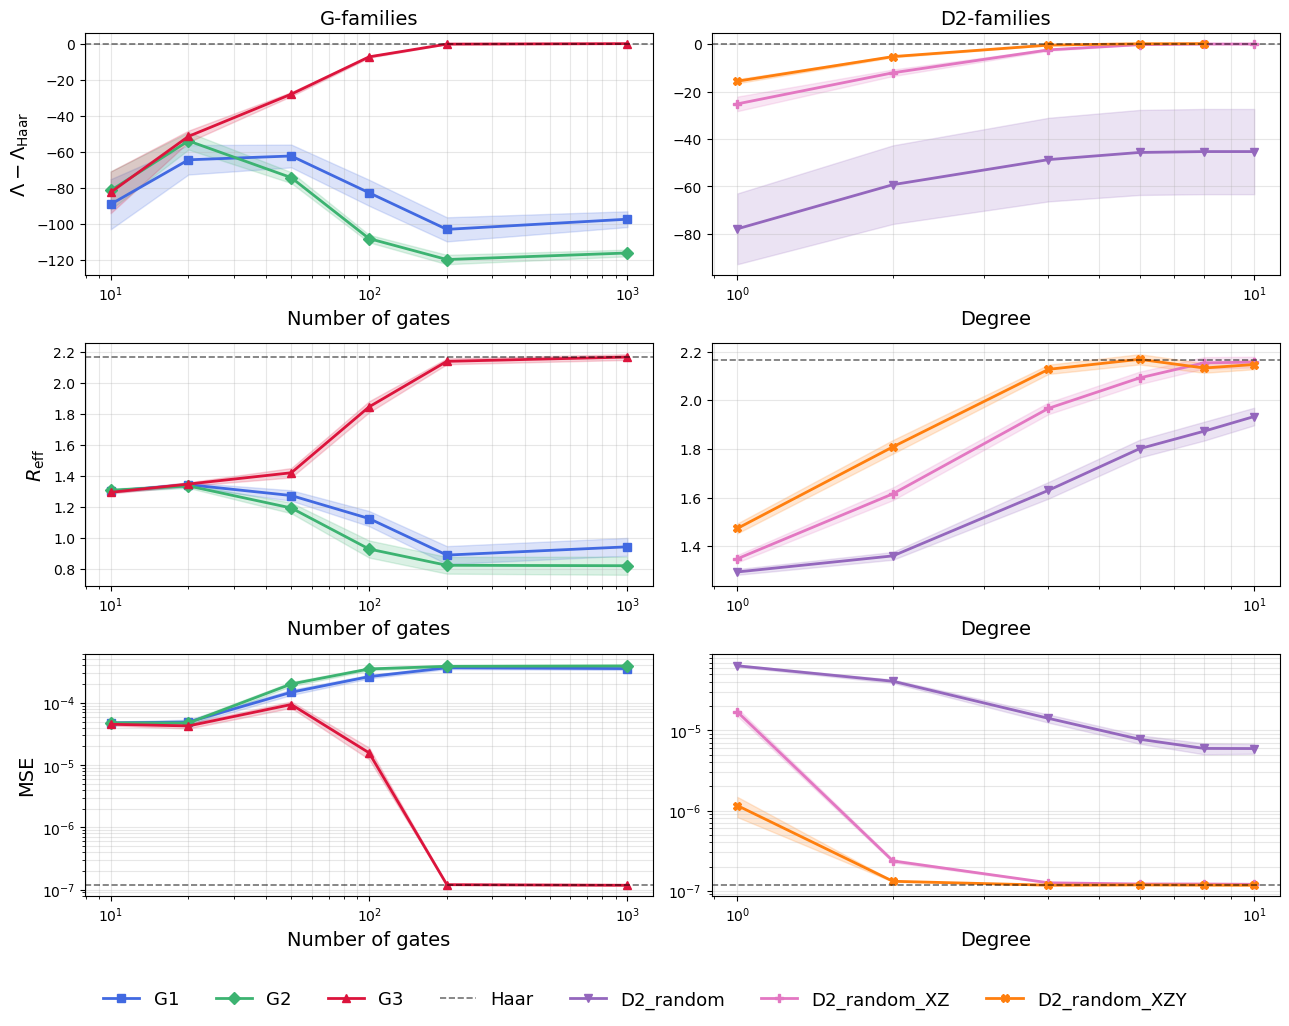

In [12]:
plot_diagnostics(
    lih_g_results, lih_d_results, lih_haar_ref,
    metric_label='MSE', log_metric=True,
    save_path=os.path.join('figures', 'fig_LiH.png'),
)

## Part 2: QRC on EMSIG Electricity Demand Forecasting

**Dataset.** The EMSIG dataset contains hourly active power consumption (kW) from a set of energy management systems (EMS). We use a single EMS unit (`ems_3`), selecting $N = 5000$ consecutive hourly measurements.

**Task.** 1-step-ahead autoregressive forecasting: given the current consumption, predict the next hour's consumption. The sequence is split 70 / 15 / 15 into train / validation / test.

**Protocol (QRC).** Each input value is Pauli-encoded into 3 qubits. A fixed random reservoir circuit produces $k$-local Pauli observable features that carry temporal memory via the autoregressive feedback loop. A Ridge regression readout is trained on the training set and re-fitted on train+val before evaluating on the test set.

**Sweep.** Same circuit families and complexity parameters as Part 1. Performance is measured by the coefficient of determination $R^2$ on the test set (higher is better).

> **Note on ORS.** The noisy-basis ORS files cover $n \in \{6, 8, 10, 12, 16\}$ qubits; $n = 3$ is not included. We therefore compute the ORS gap directly from the stored per-run ORS scores as $\Lambda_{\rm gap} = \Lambda - \Lambda_{\rm Haar}(D{=}8, K{=}4)$.

Series length: 5000  (train 3500 / val 750 / test 750)
Demand range: nan – nan kW


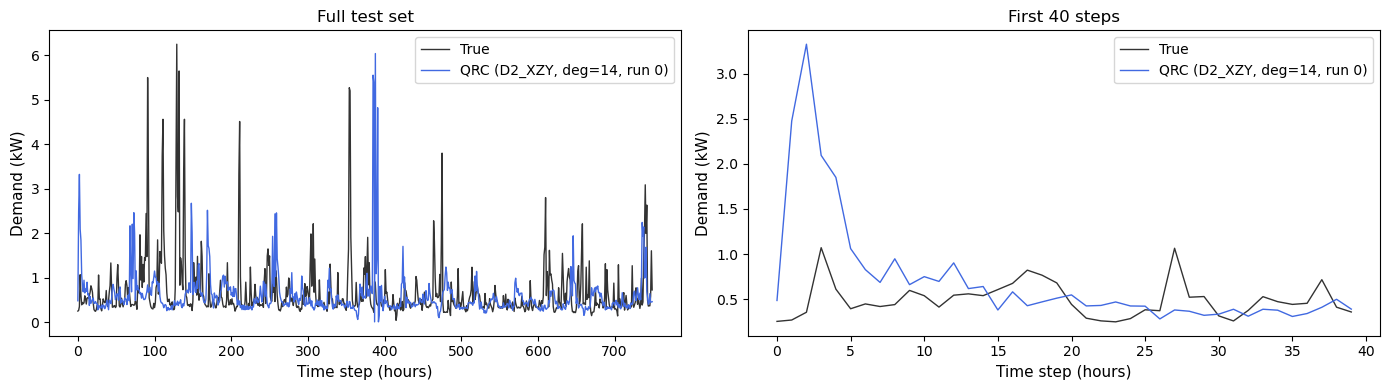

In [13]:
def _load_ems_series(ems_id='ems_3'):
    df = pd.read_csv(os.path.join('data', 'time_series', 'emsig_energy_data_by_ems.csv'))
    df = df[df['ems_id'] == ems_id].copy()
    df['time'] = pd.to_datetime(df['time'], unit='ms', utc=True)
    series = df.set_index('time').sort_index()['_sum_consumption_active_power']
    return series.resample('1h').mean().interpolate('linear', limit=4).values / 1000  # kW


y_all = _load_ems_series()[:5000]
n_tr, n_va, n_te = 3500, 750, 750
y_test_true = y_all[n_tr + n_va: n_tr + n_va + n_te]

print(f'Series length: {len(y_all)}  '
      f'(train {n_tr} / val {n_va} / test {n_te})')
print(f'Demand range: {y_all.min():.1f} – {y_all.max():.1f} kW')

# ── Load example prediction from a pre-computed result ────────────────────────
_ex_path = os.path.join('results', 'time_series', 'emsig',
                        'results_ems_3_D2_random_XZY_-1_14.0_-1_1.npz')
_ex_d = np.load(_ex_path)
y_test_pred_ex = _ex_d['y_test_pred'][0, :, 0]   # first run, shape (750,)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, sl, title in [
    (axes[0], slice(None), 'Full test set'),
    (axes[1], slice(40),   'First 40 steps'),
]:
    ax.plot(y_test_true[sl], 'k',           lw=1, alpha=0.8, label='True')
    ax.plot(y_test_pred_ex[sl], color='royalblue', lw=1,
            label='QRC (D2_XZY, deg=14, run 0)')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Time step (hours)', fontsize=11)
    ax.set_ylabel('Demand (kW)', fontsize=11)
    ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join('figures', 'emsig_example.png'), dpi=150)
plt.show()

In [28]:
QRC_DIR_EMS    = os.path.join('results', 'time_series', 'emsig')
N_EMS          = 6
METRIC_COL_EMS = 11   # test R²  (metrics_cols order: train/val/test × mae/rmse/nrmse/r2)
HAAR_ORS_EMS   = lambda_haar_largeD(2**N_EMS, K)   # Haar ORS reference for n=3

G_DEPTHS_EMS   = [10, 20, 50, 100, 200, 1000]
D2_DEGREES_EMS = [1, 2, 4, 6, 8, 10]


def _ems_path(fam, ng=-1, degree=-1.0, n_layers=-1, scrambler=-1):
    return os.path.join(QRC_DIR_EMS,
                        f'results_ems_3_{fam}_{ng}_{degree}_{scrambler}_{n_layers}.npz')


def _load_ems(fam, val, kind):
    if fam == 'Haar':
        path = _ems_path('Haar')
    elif kind == 'ng':
        path = _ems_path(fam, ng=val)
    else:
        path = _ems_path(fam, degree=float(val), n_layers=1)
    if not os.path.exists(path):
        return None
    d = np.load(path)
    ors_m, ors_s = load_ors_mb(fam, val, kind, N_EMS)
    #ors_gap = d['ors'].ravel() - HAAR_ORS_EMS
    reff    = d['r_eff']                           # already stored
    perf    = d['metrics'][:, METRIC_COL_EMS]      # test R²
    return dict(
        ors_m=float(ors_m),  ors_s=float(ors_s),
        reff_m=float(reff.mean()),    reff_s=float(reff.std()    / np.sqrt(len(reff))),
        metric_m=float(perf.mean()), metric_s=float(perf.std()  / np.sqrt(len(perf))),
    )


# ── Build result dicts ─────────────────────────────────────────────────────────
emsig_g_results = {fam: {} for fam in G_FAMILIES}
for fam in G_FAMILIES:
    for ng in G_DEPTHS_EMS:
        r = _load_ems(fam, ng, 'ng')
        if r:
            emsig_g_results[fam][ng] = r

emsig_d_results = {fam: {} for fam in D2_FAMILIES}
for fam in D2_FAMILIES:
    for deg in D2_DEGREES_EMS:
        r = _load_ems(fam, deg, 'deg')
        if r:
            emsig_d_results[fam][deg] = r

_haar_ems = _load_ems('Haar', None, None)
emsig_haar_ref = {
    'ors':    0.0,
    'ors_gap':0.0,
    'reff':   _haar_ems['reff_m']   if _haar_ems else None,
    'metric': _haar_ems['metric_m'] if _haar_ems else None,
}
if _haar_ems:
    print(f'Haar  R_eff = {emsig_haar_ref["reff"]:.2f}'
          f'  R² = {emsig_haar_ref["metric"]:.4f}')

Path does not exist:  results\ors\noisy_basis\Haar_degNone_L1_100runs_seed1234_basis4321_noise_multibasis.npz
Haar  R_eff = 11.27  R² = 0.5477


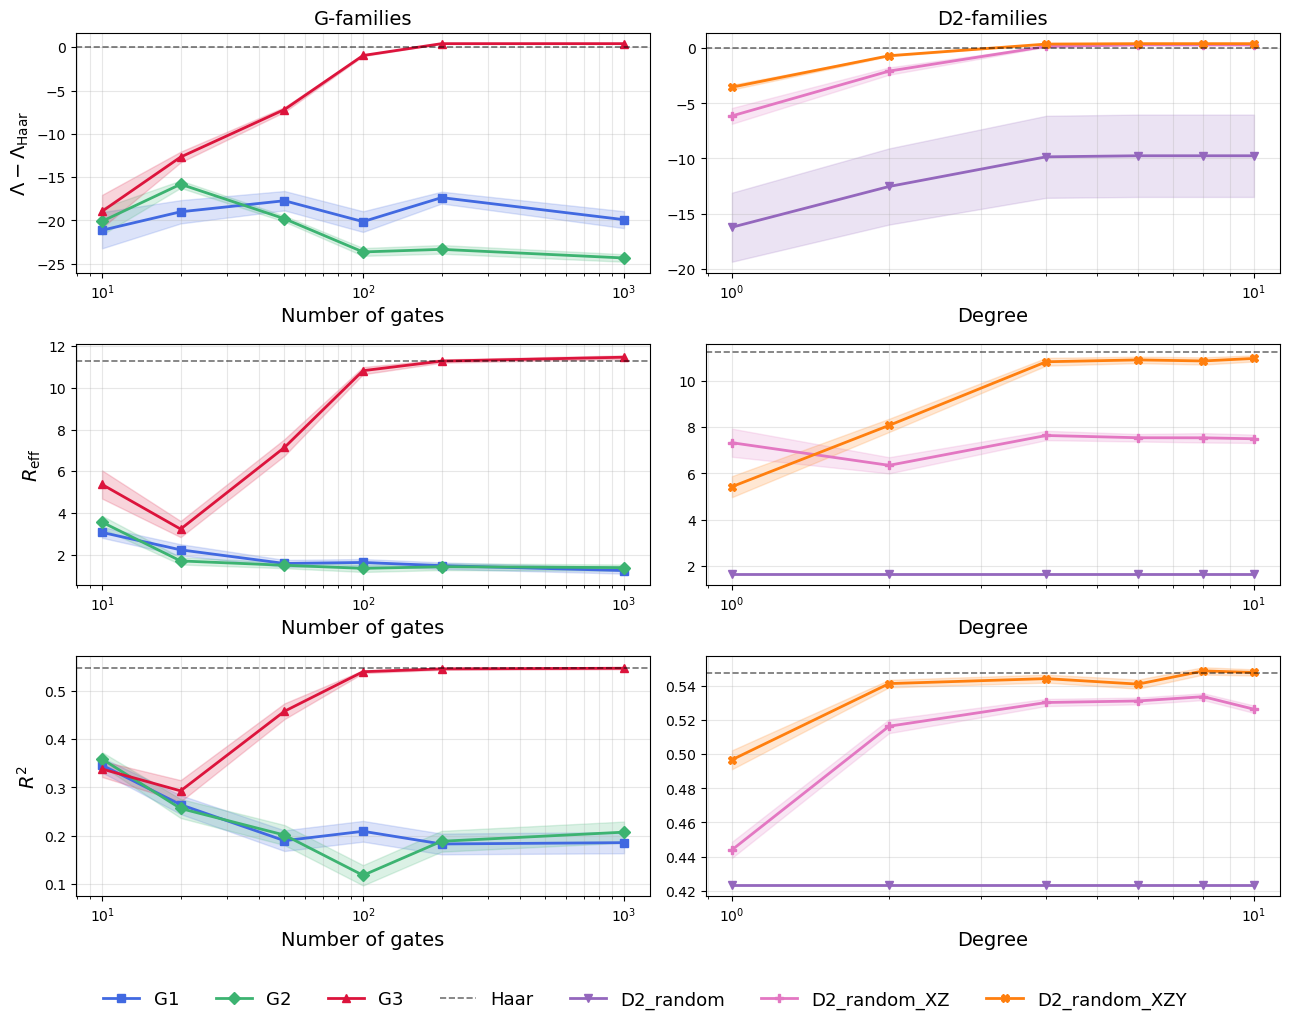

In [30]:
plot_diagnostics(
    emsig_g_results, emsig_d_results, emsig_haar_ref,
    metric_label=r'$R^2$', log_metric=False,
    save_path=os.path.join('figures', 'fig_EMSIG.png'),
)